In [66]:
import sys
import os
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(BASE_PATH)

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

from src.data_loader import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [67]:
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATASET_PATH = os.path.join(BASE_PATH, "data", "raw")

train_loader, val_loader, num_brands = get_dataloaders(DATASET_PATH)

Dataset size: 4000
Class distribution:
 label
0    2000
1    2000
Name: count, dtype: int64
Brands: 10


In [68]:
# Rebuild model architecture
class BrandAwareResNet(nn.Module):
    def __init__(self, base_model, num_brands):
        super().__init__()
        self.base = base_model
        self.base.fc = nn.Identity()

        self.brand_embedding = nn.Embedding(num_brands, 16)

        self.classifier = nn.Sequential(
            nn.Linear(2048 + 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x, brand):
        features = self.base(x)
        brand_feat = self.brand_embedding(brand)
        combined = torch.cat([features, brand_feat], dim=1)
        return self.classifier(combined)

In [69]:
# Load the model
model_path = "../models/best_model.pth"

base_model = models.resnet50(pretrained=False)
model = BrandAwareResNet(base_model, num_brands).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model loaded successfully")

d:\VIT Personal\TrustFilterAI\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\VIT Personal\TrustFilterAI\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [70]:
# Evaluation
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels, brands in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        brands = brands.to(device)

        outputs = model(images, brands)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       400
           1       0.97      0.96      0.96       400

    accuracy                           0.96       800
   macro avg       0.97      0.96      0.96       800
weighted avg       0.97      0.96      0.96       800



In [71]:
# Demo function
def predict_image(image_path, brand_name):
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    brand_id = torch.tensor([brand_to_id[brand_name]], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(img_tensor, brand_id)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    label = "FAKE" if pred == 1 else "GENUINE"
    confidence = probs[0][pred].item()

    # Show image
    plt.imshow(image)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    return label, confidence

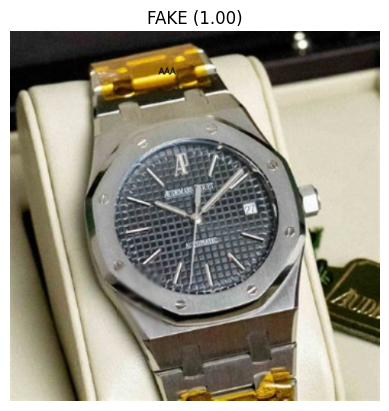

('FAKE', 0.9999619722366333)

In [72]:
# Test demo
predict_image(
    image_path="../data/raw/Audemars Piguet/fake_backup/fake_118.jpg",
    brand_name="Audemars Piguet"
)